In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import psycopg2
connection = psycopg2.connect(
    host="localhost",
    port=5433,
    database="churn_db",   # DB name
    user="customer",       # DB user
    password="customerchurn123" # DB password
)

In [4]:
data = pd.read_csv('../Datasets/churnData.csv')
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Cleaning the Dataset 



In [5]:
## Checking the null data 
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
## Checking the null values 

print(data.isna().any())

### There are no any such null values in the whole dataset!

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool


In [7]:
(data == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
novalues = data[data.TotalCharges == " "].columns

In [9]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.fillna(data['TotalCharges'].mean())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [10]:
### Lets see if other columns have the missing values
data[data['tenure'] == 0]

### here tenure = 0 means that the total months is 0 which is irrelavant for this dataset, so we will drop all those values

data.drop(labels=data[data['tenure'] == 0].index , axis = 0, inplace=True)

## We have dropped all those rows which had the missing values or irrelavant values in them.

In [11]:
### Converting to the actual dataframe for sql analysis 

data.to_csv('../Datasets/cleaned.csv')

---
### EDA with SQL, Matplotlib, Pandas, and Seaborn 

--- 
### Gender Distribution in the dataset 



In [12]:
query = """select "gender", count(*) as total 
from cleaned
group by "gender" """

gender_distribution = pd.read_sql(query, connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/3318677407.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gender_distribution = pd.read_sql(query, connection)


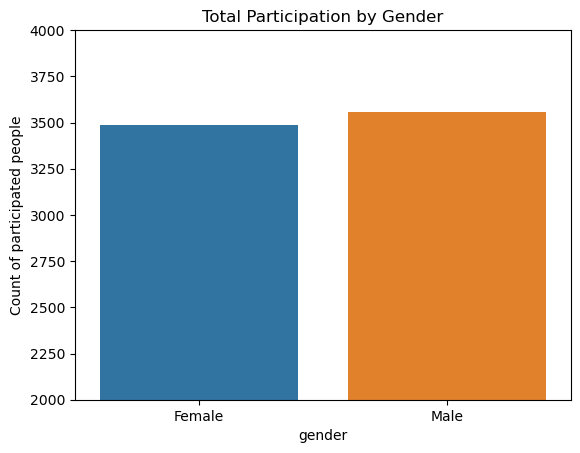

In [13]:
sns.barplot(x = 'gender', y = 'total', data = gender_distribution, hue = 'gender')
plt.ylabel("Count of participated people")
plt.ylim(2000,4000)
plt.title("Total Participation by Gender")
plt.show()

---
### Senior Citizen Participation in the datsets


In [14]:
query = """ select "SeniorCitizen", count(*) as total 
from cleaned
group by "SeniorCitizen"
"""

seniorparticipation = pd.read_sql(query,connection)
seniorparticipation['SeniorCitizen'] = seniorparticipation['SeniorCitizen'].map({0:'No',1:'Yes'})

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/617855046.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  seniorparticipation = pd.read_sql(query,connection)


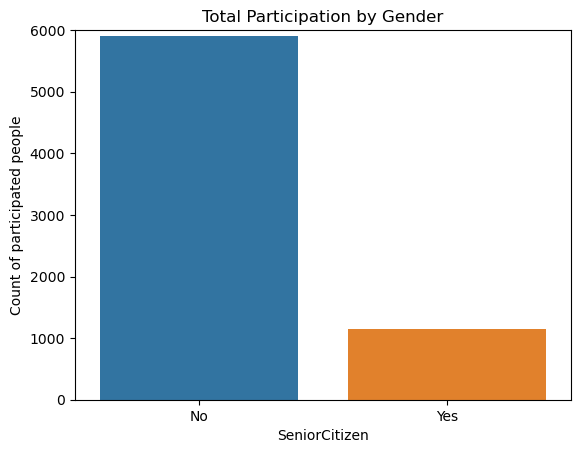

In [15]:
sns.barplot(x = 'SeniorCitizen', y = 'total', data = seniorparticipation, hue = 'SeniorCitizen')
plt.ylabel("Count of participated people")
plt.ylim(0,6000)
plt.title("Total Participation by Gender")
plt.show()

---

### Count of the total churn customers vs non-churn 


In [16]:
query = """
select "Churn", count(*) as total
from cleaned
group by "Churn"
"""

churndetails = pd.read_sql(query, connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/207033286.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  churndetails = pd.read_sql(query, connection)


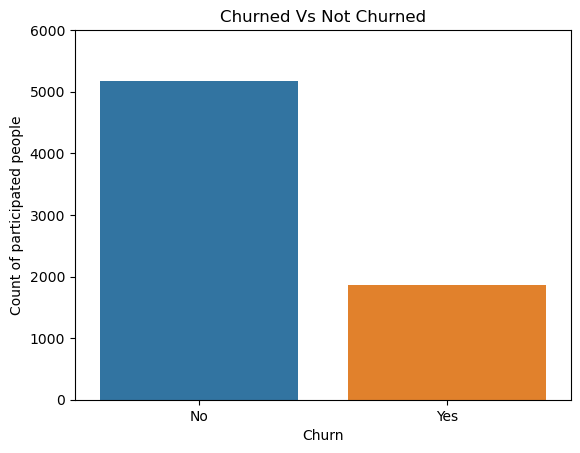

In [17]:
sns.barplot(x = 'Churn', y = 'total', data = churndetails, hue = 'Churn')
plt.ylabel("Count of participated people")
plt.ylim(0,6000)
plt.title("Churned Vs Not Churned")
plt.show()

---
### Average Tenure for churned vs non churned customers


In [18]:
query = """
    select "Churn", ROUND(avg("tenure")::numeric, 0) as average
    from cleaned
    group by "Churn"
"""
averagemonths = pd.read_sql(query,connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/193009145.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  averagemonths = pd.read_sql(query,connection)


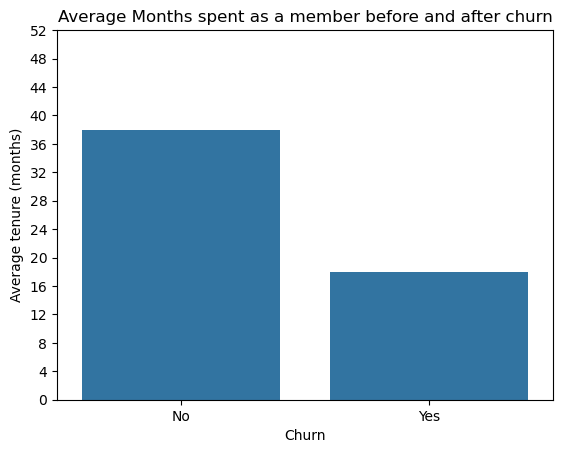

In [19]:
sns.barplot(x = 'Churn', y = 'average', data = averagemonths)
plt.ylabel("Average tenure (months)")
plt.ylim(0,50)
plt.title("Average Months spent as a member before and after churn")
plt.yticks(np.arange(0,54,4))
plt.show()

---
### Relation between the Average Monthly Charge and Churn Customers 


In [20]:
query = """
select "Churn", ROUND(AVG("MonthlyCharges")::numeric ,2) as amountPaid
from cleaned
group by "Churn" 
"""

monthlyaveragechurned = pd.read_sql(query, connection)
monthlyaveragechurned.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/4052769378.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthlyaveragechurned = pd.read_sql(query, connection)


,Churn,amountpaid
0,No,61.27
1,Yes,74.44


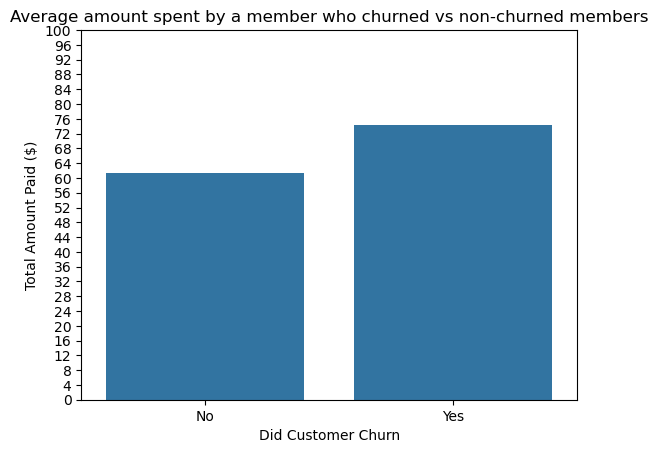

In [21]:
### Total Amount Paid by the churn vs non-churn customers
sns.barplot(x = 'Churn', y = 'amountpaid', data = monthlyaveragechurned)
plt.xlabel("Did Customer Churn")
plt.ylabel("Total Amount Paid ($)")
plt.ylim(0,100)
plt.title("Average amount spent by a member who churned vs non-churned members")
plt.yticks(np.arange(0,102,4))
plt.show()

### As we can see the amount paid by customer who churned was 13$ more on average compared to the one who did not churn. This suggests us that the price might also be a factor on why the customer churned

---

### Types of Contract of the Churned Customers

In [22]:
query = """ 
select "Contract", ROUND(100 * SUM(case when "Churn" = 'Yes' then 1 else 0 end)::numeric/count(*),2) as eachcategory 
from cleaned
group by "Contract"

"""
contract_churn = pd.read_sql(query, connection)
contract_churn.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/1758664510.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contract_churn = pd.read_sql(query, connection)


,Contract,eachcategory
0,One year,11.27
1,Month-to-month,42.71
2,Two year,2.83


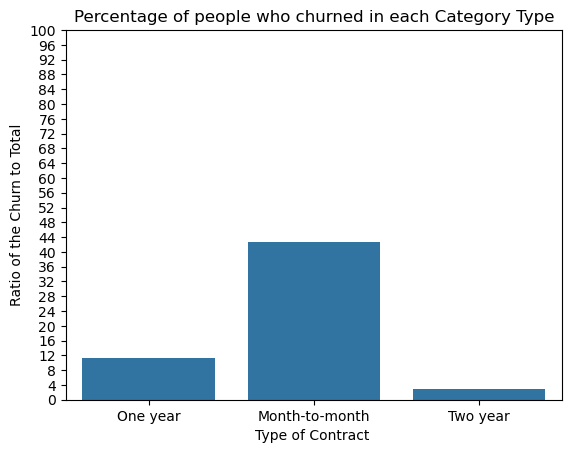

In [23]:
sns.barplot(x = 'Contract', y = 'eachcategory', data = contract_churn)
plt.xlabel("Type of Contract ")
plt.ylabel("Ratio of the Churn to Total")
plt.ylim(0,100)
plt.title("Percentage of people who churned in each Category Type")
plt.yticks(np.arange(0,104,4))
plt.show()

### As seen there are more month-to-month category users who churned compared to other category types suggesting the category types may also effect user's decisions.

---
### Types of Payment Method used by Churned Customers 

In [24]:
query = """ 
select "PaymentMethod", ROUND(100 * SUM(case when "Churn" = 'Yes' then 1 else 0 end)::numeric/count(*),2) as paymentratio
from cleaned
group by "PaymentMethod" 
"""

paymentused = pd.read_sql(query,connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/1581882869.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  paymentused = pd.read_sql(query,connection)


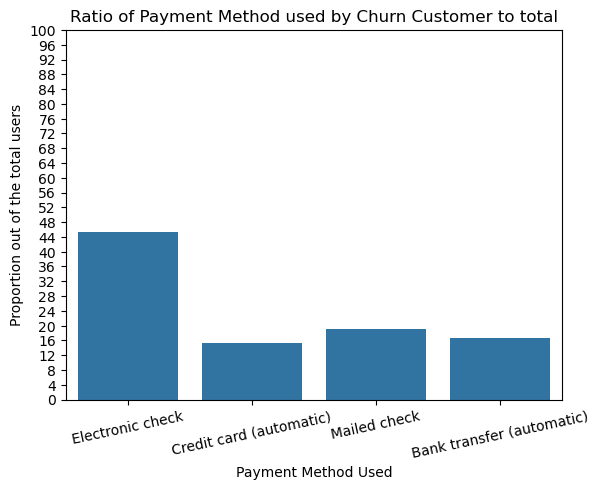

In [25]:
sns.barplot(x = 'PaymentMethod', y = 'paymentratio', data = paymentused)
plt.xlabel("Payment Method Used")
plt.ylabel("Proportion out of the total users")
plt.ylim(0,100)
plt.title("Ratio of Payment Method used by Churn Customer to total")
plt.yticks(np.arange(0,104,4))
plt.xticks(rotation = 12)
plt.show()

### As seen from the chart, Electronic Check were the most used payment method used by the customers who churned

---

### Lets see what percent of total revenue loss is done by each payment category in Month-Month Contract. Month-Month contract has been choosen because nearly half of the churned customers fall in the Month-Month Contract
 

In [26]:
query = """ 
with monthtomonth as (
	select "Contract", "PaymentMethod", SUM("TotalCharges") as totalrevenue
	from cleaned
	where "Contract" = 'Month-to-month' and "Churn" = 'Yes' 
	group by "Contract", "PaymentMethod"
), 
totalloss as (
select "Contract", SUM("TotalCharges") as totalloss
from cleaned
where "Contract" = 'Month-to-month' and "Churn" = 'Yes'
group by "Contract"
)

select m."Contract", m."PaymentMethod", 100 * (m.totalrevenue/t.totalloss )as percent
from monthtomonth as m 
join totalloss as t
on m."Contract" = t."Contract"
"""

monthspecific = pd.read_sql(query, connection)

print(monthspecific)

         Contract              PaymentMethod    percent
0  Month-to-month           Electronic check  62.678951
1  Month-to-month    Credit card (automatic)  15.172946
2  Month-to-month               Mailed check   5.717602
3  Month-to-month  Bank transfer (automatic)  16.430457


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/3813486424.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthspecific = pd.read_sql(query, connection)


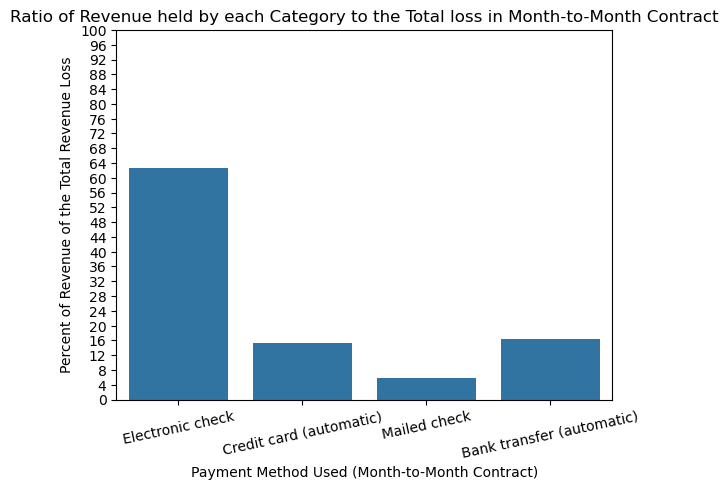

In [27]:
sns.barplot(x = 'PaymentMethod', y = 'percent', data = monthspecific)
plt.xlabel("Payment Method Used (Month-to-Month Contract)")
plt.ylabel("Percent of Revenue of the Total Revenue Loss")
plt.ylim(0,100)
plt.title("Ratio of Revenue held by each Category to the Total loss in Month-to-Month Contract")
plt.yticks(np.arange(0,104,4))
plt.xticks(rotation = 12)
plt.show()

### As seen from the graph electronic check method holds the highest revenue out of the total loss generated from the Month-Month Contract

---
### Evaluating the tenure of the churned customers

In [28]:
## Here we have seperated the months in terms of years

query = """ 
with tenureyears as (select *,
case 
	when "tenure" >=0 and "tenure" <= 12 then '12 months'
	when "tenure" > 12 and "tenure" <= 24 then '24 months'
	when "tenure" > 24 and "tenure" <= 48 then '48 months'
	else '4 years +'
end as tenureyears

from cleaned)


select "tenureyears", count(*) as total
from tenureyears
where "Churn" = 'Yes'
group by tenureyears
order by "tenureyears"
"""

monthlytenure = pd.read_sql(query, connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/63829831.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthlytenure = pd.read_sql(query, connection)


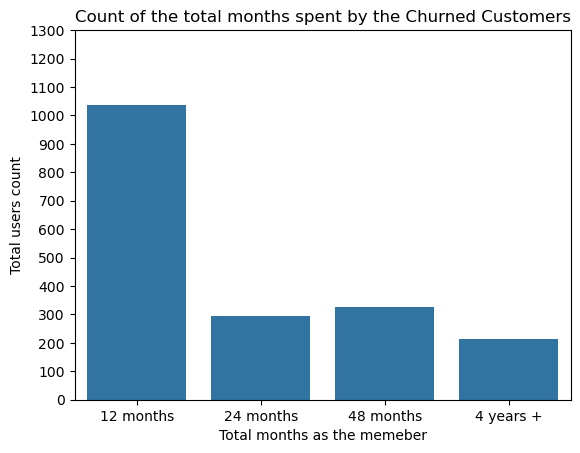

In [29]:
sns.barplot(x = 'tenureyears', y = 'total', data = monthlytenure)
plt.yticks(np.arange(0,1400,100))
plt.xlabel("Total months as the memeber")
plt.ylabel("Total users count")
plt.title("Count of the total months spent by the Churned Customers")
plt.show()

### We can see most of the customers who churned had the average tenure of 12 months, whereas 4 years+ have the lowest total in the whole chart

---
### Churn rate per tenure bucket 

In [30]:
query = """ 
with tenureyears as (select *,
case 
	when "tenure" >=0 and "tenure" <= 12 then '12 months'
	when "tenure" > 12 and "tenure" <= 24 then '24 months'
	when "tenure" > 24 and "tenure" <= 48 then '48 months'
	else '4 years +'
end as tenureyears

from cleaned)

select  "tenureyears", ROUND(100* (sum(case when "Churn" = 'Yes' then 1 else 0 end)::numeric / COUNT(*)),2) as ratio
from tenureyears
group by "tenureyears"
order by "tenureyears"
"""

churnrate = pd.read_sql(query,connection)
churnrate.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/3002295333.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  churnrate = pd.read_sql(query,connection)


,tenureyears,ratio
0,12 months,47.44
1,24 months,28.71
2,48 months,20.39
3,4 years +,9.51


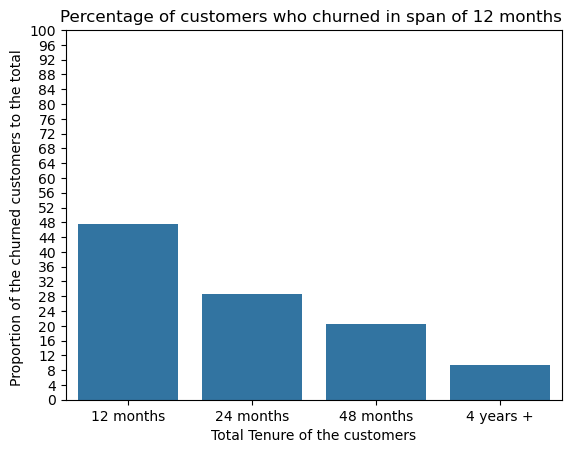

In [31]:
sns.barplot(x = 'tenureyears', y = 'ratio', data = churnrate)
plt.xlabel("Total Tenure of the customers")
plt.ylabel("Proportion of the churned customers to the total ")
plt.ylim(0,100)
plt.title("Percentage of customers who churned in span of 12 months ")
plt.yticks(np.arange(0,104,4))
plt.show()

### As seen from the graph, customers with tenure of 0–12 months have the highest churn rate compared to longer-tenured customers. This suggests that churn risk is significantly higher during the first year of the customer lifecycle, and customers are most likely to leave early rather than after long-term engagement.

---
### Service Usage Analysis !



In [32]:
query = """ 

select "InternetService",
ROUND(100 * SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END)::numeric / COUNT(*), 2) AS churn_rate
from cleaned
group by "InternetService" 
order by churn_rate desc

"""

eachservicechurn = pd.read_sql(query,connection)
print(eachservicechurn)

  InternetService  churn_rate
0     Fiber optic       41.89
1             DSL       18.96
2              No        7.40


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/3591988935.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  eachservicechurn = pd.read_sql(query,connection)


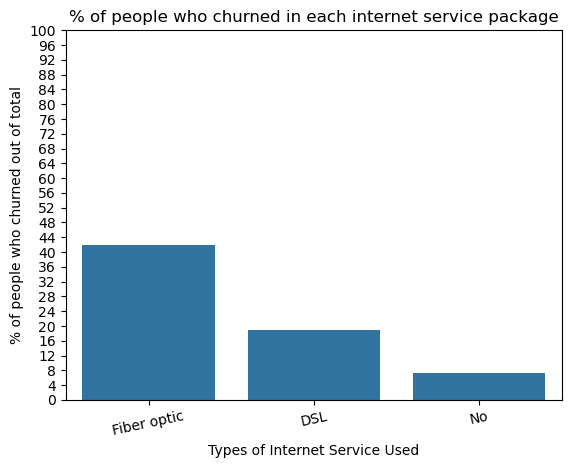

In [33]:
sns.barplot(x = 'InternetService', y = 'churn_rate', data = eachservicechurn)
plt.xlabel("Types of Internet Service Used")
plt.ylabel("% of people who churned out of total")
plt.ylim(0,100)
plt.title("% of people who churned in each internet service package")
plt.yticks(np.arange(0,104,4))
plt.xticks(rotation = 12)
plt.show()

### FiberOptic has the highest churn rate compared to other internet service methods
---

### Churn rate of the customers based on the number of services they used. Services include: Streaming TV, Streaming Movies, Online Backup, and DeviceProtection, OnlineSecurity, Tech Support 

In [34]:
query = """ 
with each_service as (
	
	select *,
	(case when "StreamingTV" = 'Yes' then 1 else 0 end + 
	 case when "StreamingMovies" = 'Yes' then 1 else 0 end + 
	 case when "OnlineBackup" = 'Yes' then 1 else 0 end + 
	 case when "DeviceProtection" = 'Yes' then 1 else 0 end +
	 case when "OnlineSecurity" = 'Yes' then 1 else 0 end+
	 case when "TechSupport" = 'Yes' then 1 else 0 end) as total_services_used
	from cleaned
	where "InternetService" <> 'No'
	
)

select total_services_used,
ROUND(100 * SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END)::numeric / COUNT(*), 2)
from each_service
group by total_services_used

"""

serviceschurnrate = pd.read_sql(query,connection)
serviceschurnrate.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/1408032721.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  serviceschurnrate = pd.read_sql(query,connection)


,total_services_used,round
0,4,22.30
1,6,5.28
2,2,35.82
3,3,27.37
4,0,52.24


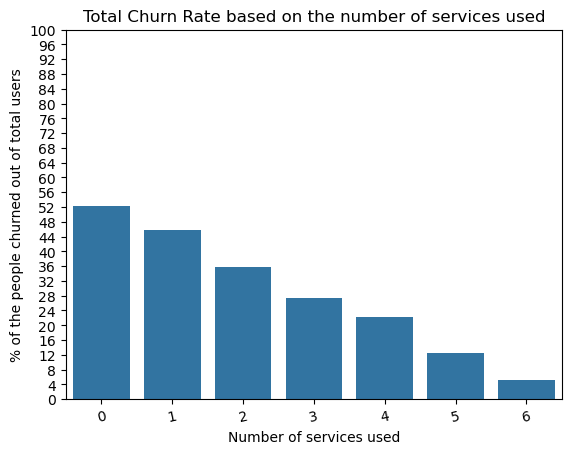

In [35]:
### Graphical representation 

sns.barplot(x = 'total_services_used', y = 'round', data = serviceschurnrate)
plt.ylabel("% of the people churned out of total users")
plt.xlabel("Number of services used")
plt.ylim(0,100)
plt.title("Total Churn Rate based on the number of services used")
plt.yticks(np.arange(0,104,4))
plt.xticks(rotation = 12)
plt.show()

### Average total charges for churned vs non churned customers 



In [36]:
query = """
select ROUND(AVG("TotalCharges")::numeric,2) as avg_cost_paid, "Churn"
from cleaned
group by "Churn"
"""

averageCost = pd.read_sql(query,connection)

averageCost.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/2119405833.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  averageCost = pd.read_sql(query,connection)


,avg_cost_paid,Churn
0,2555.34,No
1,1531.80,Yes


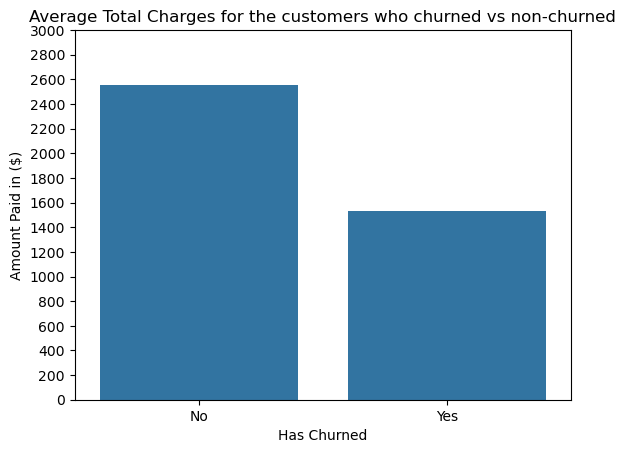

In [37]:
sns.barplot(x = 'Churn', y = 'avg_cost_paid', data = averageCost)
plt.ylabel("Amount Paid in ($)")
plt.xlabel("Has Churned")
plt.ylim(0,3000)
plt.title("Average Total Charges for the customers who churned vs non-churned")
plt.yticks(np.arange(0,3200,200))
plt.show()

---
### Distribution of Monthly Charges for Churned vs Non Churned Customers


In [38]:
query = """ 

select "MonthlyCharges", "Churn"
from cleaned 

"""

monthlystats = pd.read_sql(query,connection)

print(monthlystats)

      MonthlyCharges Churn
0              29.85    No
1              56.95    No
2              53.85   Yes
3              42.30    No
4              70.70   Yes
...              ...   ...
7038           84.80    No
7039          103.20    No
7040           29.60    No
7041           74.40   Yes
7042          105.65    No

[7043 rows x 2 columns]


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/1842107752.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthlystats = pd.read_sql(query,connection)


In [39]:
query = """ 

select "MonthlyCharges", "Churn"
from cleaned 

"""
monthlystats = pd.read_sql(query,connection)
monthlystats.head()

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/2473097056.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthlystats = pd.read_sql(query,connection)


,MonthlyCharges,Churn
0,29.85,No
1,56.95,No
2,53.85,Yes
3,42.30,No
4,70.70,Yes


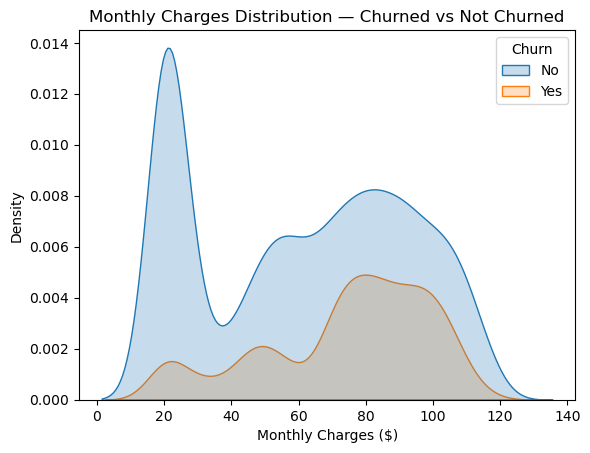

In [40]:
sns.kdeplot(data = monthlystats,x = 'MonthlyCharges', hue = 'Churn', fill=True)
plt.title("Monthly Charges Distribution — Churned vs Not Churned")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.show()

---

### Profile of the customers 

### Customers with the Tenure of more than 48 months 
---
### Total Money Paid Stats

In [41]:
query = """ 
with amountstats as (
select "Churn", ROUND(AVG("MonthlyCharges")::numeric,2) as averagemonthly, ROUND(AVG("TotalCharges")::numeric,2) as totalcharges,COUNT(*) as totalchurn 
from cleaned
where "tenure" >= 48
group by "Churn")

select * from amountstats
"""

moneyfouryears = pd.read_sql(query, connection)
moneyfouryears.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_83432/41002306.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  moneyfouryears = pd.read_sql(query, connection)


,Churn,averagemonthly,totalcharges,totalchurn
0,No,71.74,4552.89,2081
1,Yes,91.82,5466.75,222


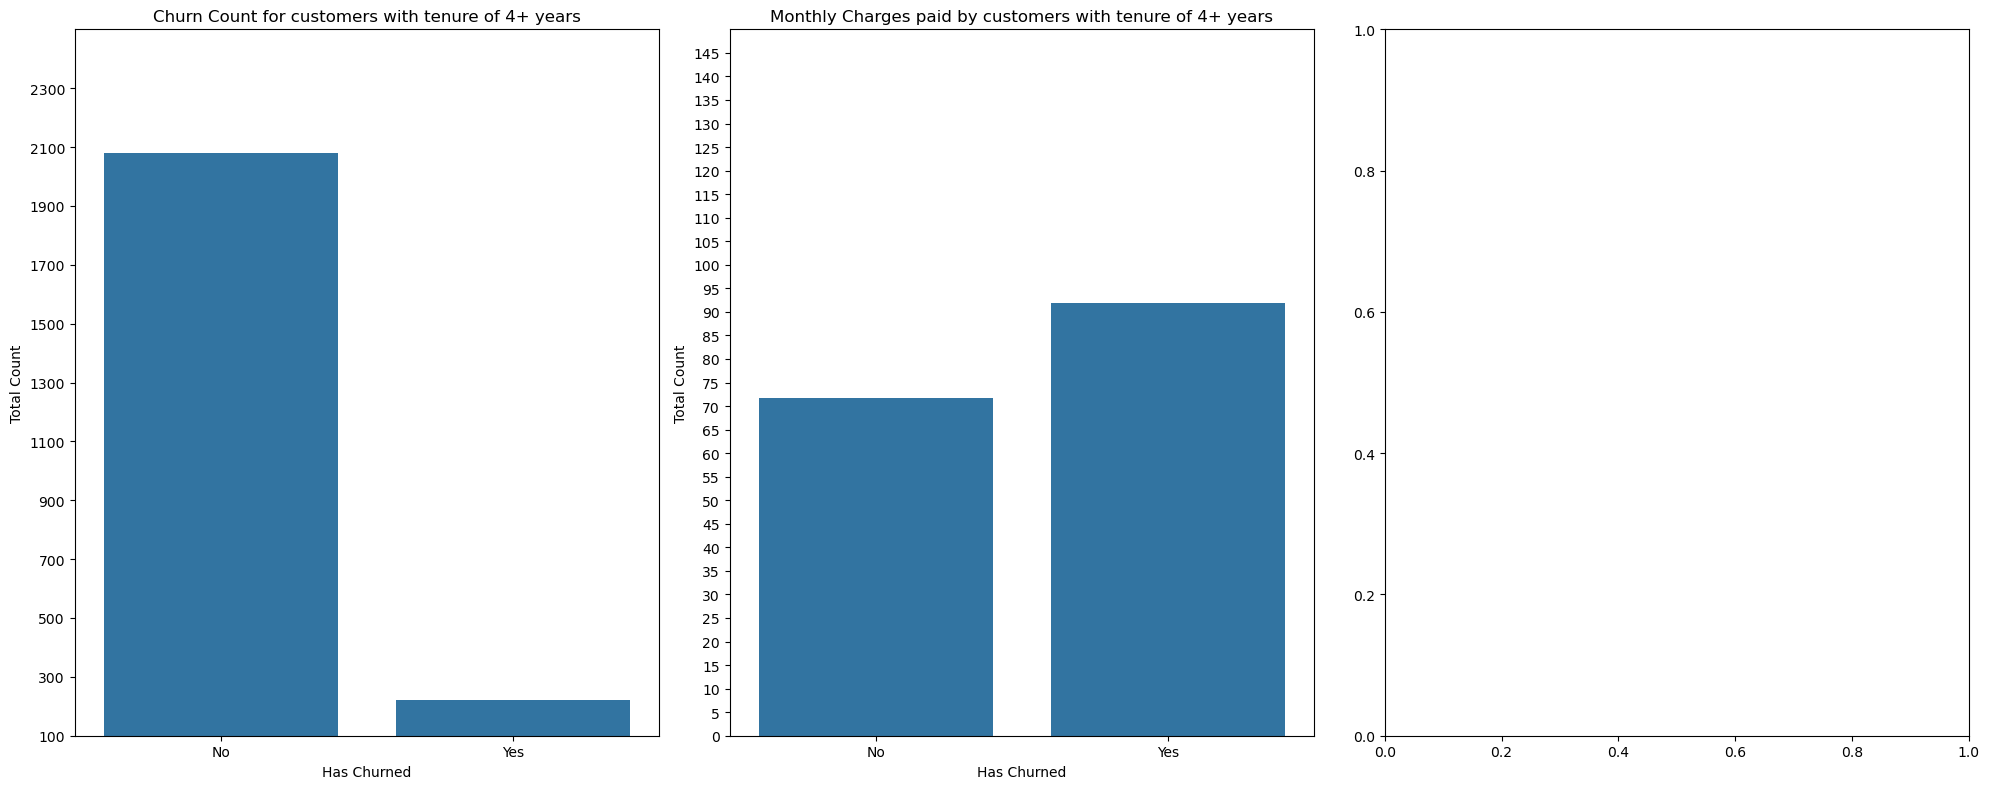

In [ ]:
### Stack Bar Graph of the amount paid by the customers with 4+ years of tenure 
fig, ax = plt.subplots(1,3,figsize = (20,8))
def plotting_charges(x, y , data, title, xlabel, ylabel, ylim1,ylim2, axes,num):
    sns.barplot(x = x, y = y , data = data, ax = axes)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.set_yticks(np.arange(ylim1,ylim2, num))
    axes.set_ylim(ylim1, ylim2)
    axes.yaxis.set_visible(True)
    plt.tight_layout()

plotting_charges('Churn','totalchurn', moneyfouryears, 'Churn Count for customers with tenure of 4+ years', 'Has Churned', 'Total Count', 100,2500, ax[0],200)
plotting_charges('Churn','averagemonthly', moneyfouryears, 'Average Monthly Charges paid by customers with tenure of 4+ years', 'Has Churned', 'Total Count', 0,150, ax[1], 5)